In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

training_dataset = pd.read_csv('../data/raw/train.csv')
testing_dataset = pd.read_csv('../data/raw/test.csv')

train_dimensions = training_dataset.shape
test_dimensions = testing_dataset.shape

print("Train shape:", train_dimensions)
print("Test shape:", test_dimensions)

print("\nFirst 5 rows:")
first_five_rows = training_dataset.head()
print(first_five_rows)

Train shape: (577347, 12)
Test shape: (247435, 11)

First 5 rows:
   id       alpha      delta          u          g          r          i  \
0   0  147.734256  16.959273  25.472123  21.895559  20.357926  19.257113   
1   1  127.988677  32.346716  20.778509  19.087062  17.587208  17.226067   
2   2  179.792648  35.344843  21.035203  21.079128  21.171840  20.582629   
3   3  225.818295  48.569421  23.305056  21.050736  19.017754  18.365658   
4   4  141.836135  19.342852  21.703158  19.471680  18.234449  17.899447   

           z  redshift spectral_type galaxy_population   class  
0  18.621057  0.408982             M      Red_Sequence  GALAXY  
1  16.786433  0.157976             M      Red_Sequence  GALAXY  
2  20.557366  2.823770           O/B        Blue_Cloud     QSO  
3  17.914952  0.536099             M      Red_Sequence  GALAXY  
4  17.616185  0.555761             M      Red_Sequence  GALAXY  


# Phase A — Data එක තේරුම් ගැනීම

### 1. Column Types

In [2]:
print("=== Column Data Types ===")
column_data_types = training_dataset.dtypes
print(column_data_types)

print("\n=== Numerical vs Categorical Columns ===")
numerical_columns = training_dataset.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = training_dataset.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"Numerical ({len(numerical_columns)}):", numerical_columns)
print(f"Categorical ({len(categorical_columns)}):", categorical_columns)

=== Column Data Types ===
id                     int64
alpha                float64
delta                float64
u                    float64
g                    float64
r                    float64
i                    float64
z                    float64
redshift             float64
spectral_type            str
galaxy_population        str
class                    str
dtype: object

=== Numerical vs Categorical Columns ===
Numerical (9): ['id', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
Categorical (3): ['spectral_type', 'galaxy_population', 'class']


### 2. Cardinality

In [3]:
print("=== Column Cardinality ===")
column_cardinality = training_dataset.nunique().sort_values(ascending=False)
print(column_cardinality)

print("\n=== Cardinality Ratio (Unique / Total Rows) ===")
total_train_records = len(training_dataset)
cardinality_ratio = (column_cardinality / total_train_records * 100).round(3)
print(cardinality_ratio)

=== Column Cardinality ===
id                   577347
u                    577347
r                    577347
g                    577347
i                    577347
z                    577347
redshift             573975
delta                444062
alpha                439819
spectral_type             4
class                     3
galaxy_population         2
dtype: int64

=== Cardinality Ratio (Unique / Total Rows) ===
id                   100.000
u                    100.000
r                    100.000
g                    100.000
i                    100.000
z                    100.000
redshift              99.416
delta                 76.914
alpha                 76.179
spectral_type          0.001
class                  0.001
galaxy_population      0.000
dtype: float64


# Phase B — Data Cleaning

### 3. Duplicates

In [4]:
print("=== Duplicate Rows (Train) ===")
duplicate_row_count = training_dataset.duplicated().sum()
duplicate_row_percentage = (duplicate_row_count / len(training_dataset)) * 100
print(f"Total duplicate rows: {duplicate_row_count:,} ({duplicate_row_percentage:.3f}%)")

print("\n=== Duplicate Rows (Test) ===")
test_duplicate_row_count = testing_dataset.duplicated().sum()
print(f"Total duplicate rows: {test_duplicate_row_count:,}")

=== Duplicate Rows (Train) ===
Total duplicate rows: 0 (0.000%)

=== Duplicate Rows (Test) ===
Total duplicate rows: 0


### 4. Missing Data

In [5]:
print("=== Missing Values (Train) ===")
missing_values_per_column = training_dataset.isnull().sum()
print(missing_values_per_column)

print("\n=== Missing Values (Test) ===")
test_missing_values_per_column = testing_dataset.isnull().sum()
print(test_missing_values_per_column)

print("\n=== Missing Value Percentage (Train) ===")
missing_value_percentage = (missing_values_per_column / len(training_dataset) * 100).round(3)
print(missing_value_percentage)

=== Missing Values (Train) ===
id                   0
alpha                0
delta                0
u                    0
g                    0
r                    0
i                    0
z                    0
redshift             0
spectral_type        0
galaxy_population    0
class                0
dtype: int64

=== Missing Values (Test) ===
id                   0
alpha                0
delta                0
u                    0
g                    0
r                    0
i                    0
z                    0
redshift             0
spectral_type        0
galaxy_population    0
dtype: int64

=== Missing Value Percentage (Train) ===
id                   0.0
alpha                0.0
delta                0.0
u                    0.0
g                    0.0
r                    0.0
i                    0.0
z                    0.0
redshift             0.0
spectral_type        0.0
galaxy_population    0.0
class                0.0
dtype: float64


# Phase C — Univariate Analysis (එක Column එකක්ම විස්තර කිරීම)

### 5. Descriptive Statistics

In [6]:
print("=== Descriptive Statistics (Numerical) ===")
dataset_summary_statistics = training_dataset.describe()
print(dataset_summary_statistics)

print("\n=== Descriptive Statistics (Categorical) ===")
categorical_summary_statistics = training_dataset.describe(include=['object', 'str'])
print(categorical_summary_statistics)


=== Descriptive Statistics (Numerical) ===
                 id          alpha          delta              u  \
count  577347.00000  577347.000000  577347.000000  577347.000000   
mean   288673.00000     181.616673      21.834654      22.441926   
std    166665.86727      96.242941      18.933570       2.018135   
min         0.00000       0.011684     -17.966988      -0.139225   
25%    144336.50000     132.161499       2.474097      20.977090   
50%    288673.00000     188.681465      21.484412      22.570222   
75%    433009.50000     231.829693      36.988310      23.869103   
max    577346.00000     359.999810      79.158322      28.253263   

                   g              r              i              z  \
count  577347.000000  577347.000000  577347.000000  577347.000000   
mean       21.007273      19.962811      19.378911      19.041136   
std         1.795426       1.648964       1.580059       1.584365   
min        13.535483      12.579407      11.962781      11.682803   

### 6. Distribution & Shapes

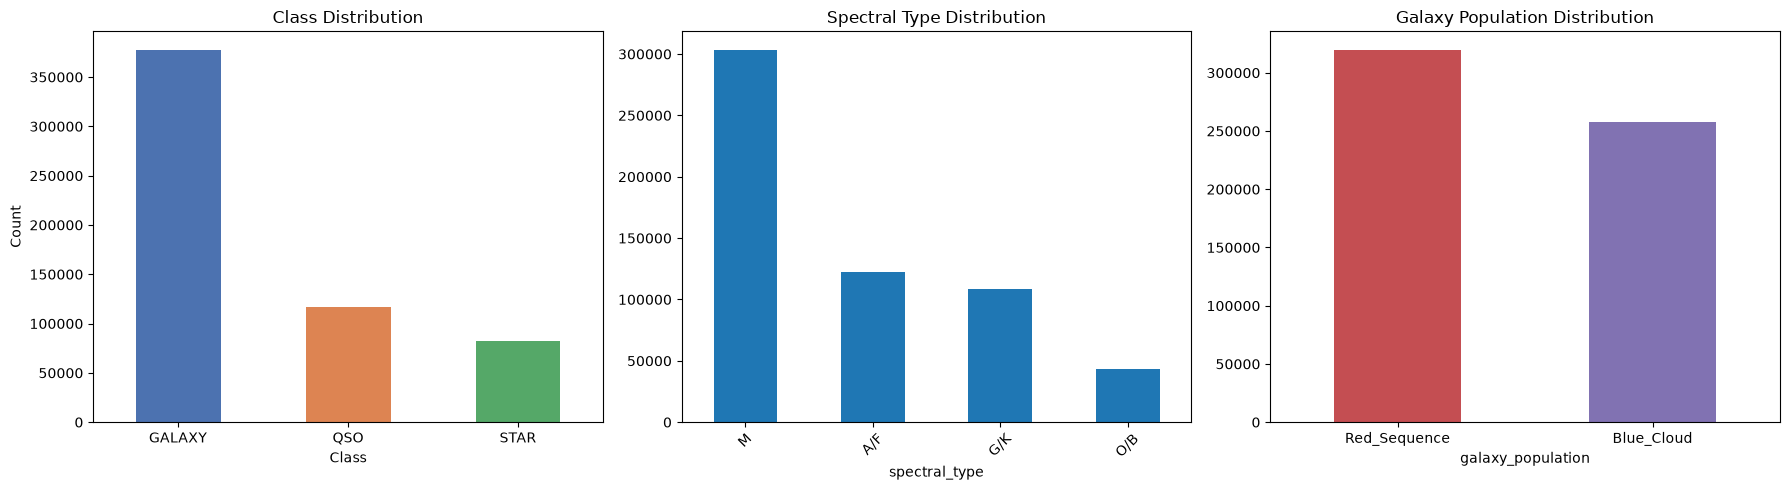

In [7]:
# Constants
CLASS_LABELS = ['GALAXY', 'QSO', 'STAR']
CLASS_COLOR_PALETTE = ['#4C72B0', '#DD8452', '#55A868']

# Figure Setup
figure, plot_axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Class distribution
class_counts = training_dataset['class'].value_counts()
class_counts.plot(kind='bar', ax=plot_axes[0], color=CLASS_COLOR_PALETTE)
plot_axes[0].set_title('Class Distribution')
plot_axes[0].set_xlabel('Class')
plot_axes[0].set_ylabel('Count')
plot_axes[0].tick_params(axis='x', rotation=0)

# 2. Spectral type distribution
spectral_type_counts = training_dataset['spectral_type'].value_counts()
spectral_type_counts.plot(kind='bar', ax=plot_axes[1])
plot_axes[1].set_title('Spectral Type Distribution')
plot_axes[1].tick_params(axis='x', rotation=45)

# 3. Galaxy population
galaxy_population_counts = training_dataset['galaxy_population'].value_counts()
galaxy_population_counts.plot(kind='bar', ax=plot_axes[2], color=['#c44e52', '#8172b2', '#937860'])
plot_axes[2].set_title('Galaxy Population Distribution')
plot_axes[2].tick_params(axis='x', rotation=0)

# Output Management
plt.tight_layout()
plt.savefig('../eda_categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

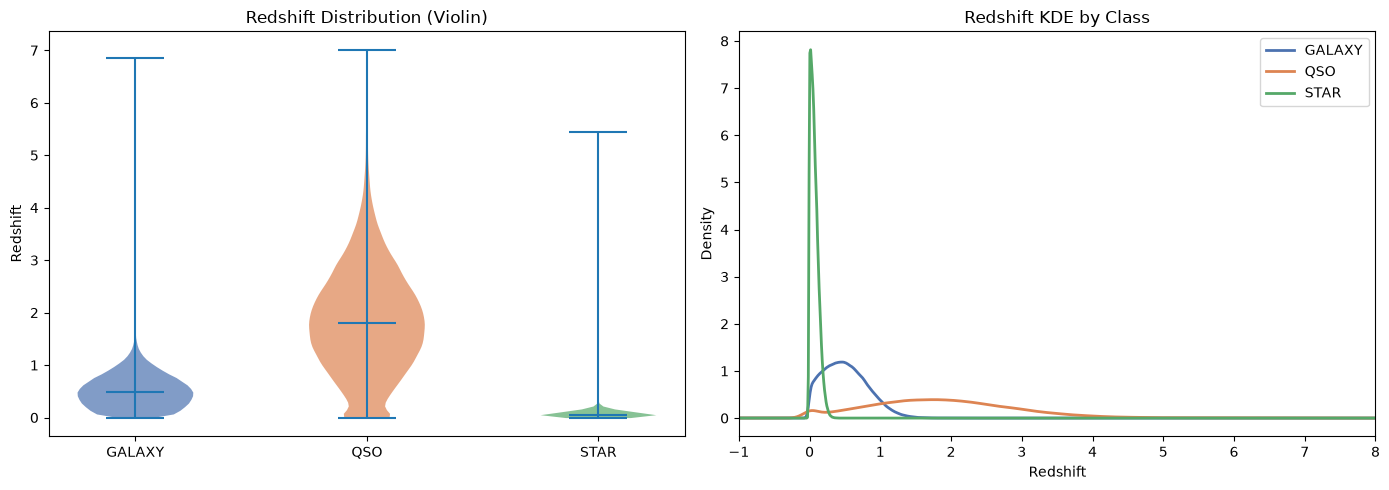

In [8]:
# Constants
CLASS_LABELS = ['GALAXY', 'QSO', 'STAR']
CLASS_COLOR_PALETTE = ['#4C72B0', '#DD8452', '#55A868']
VIOLIN_POSITIONS = [1, 2, 3]
KDE_X_LIMITS = (-1, 8)

# Figure Setup
figure, plot_axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Violin plot
redshift_data_per_class = [
    training_dataset[training_dataset['class'] == class_label]['redshift'].values
    for class_label in CLASS_LABELS
]

violin_parts = plot_axes[0].violinplot(
    redshift_data_per_class,
    positions=VIOLIN_POSITIONS,
    showmedians=True
)

for violin_body, class_color in zip(violin_parts['bodies'], CLASS_COLOR_PALETTE):
    violin_body.set_facecolor(class_color)
    violin_body.set_alpha(0.7)

plot_axes[0].set_xticks(VIOLIN_POSITIONS)
plot_axes[0].set_xticklabels(CLASS_LABELS)
plot_axes[0].set_title('Redshift Distribution (Violin)')
plot_axes[0].set_ylabel('Redshift')

# 2. KDE plot
for class_label, class_color in zip(CLASS_LABELS, CLASS_COLOR_PALETTE):
    class_subset = training_dataset[training_dataset['class'] == class_label]
    redshift_values = class_subset['redshift']
    redshift_values.plot.kde(ax=plot_axes[1], label=class_label, color=class_color, linewidth=2)

plot_axes[1].set_title('Redshift KDE by Class')
plot_axes[1].set_xlabel('Redshift')
plot_axes[1].legend()
plot_axes[1].set_xlim(KDE_X_LIMITS)

# Output Management
plt.tight_layout()
plt.savefig('../eda_redshift_shape.png', dpi=150, bbox_inches='tight')
plt.show()

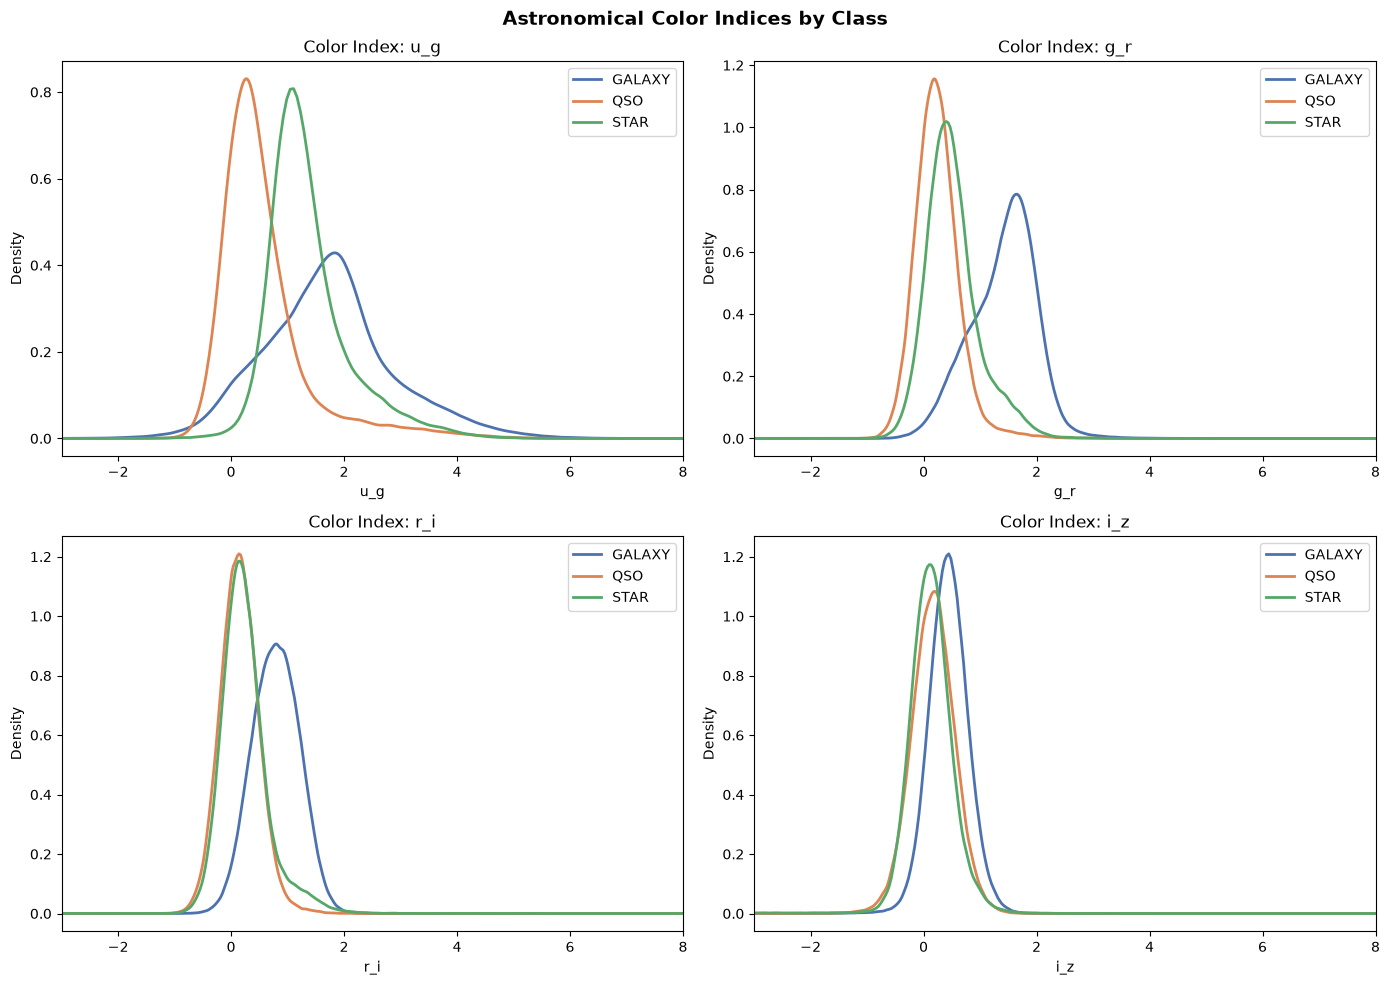

In [9]:
# Constants
CLASS_LABELS = ['GALAXY', 'QSO', 'STAR']
CLASS_COLOR_PALETTE = ['#4C72B0', '#DD8452', '#55A868']
COLOR_INDEX_COLUMNS = ['u_g', 'g_r', 'r_i', 'i_z']
KDE_X_LIMITS = (-3, 8)

# Feature Engineering
train_features_extended = training_dataset.copy()
train_features_extended['u_g'] = train_features_extended['u'] - train_features_extended['g']
train_features_extended['g_r'] = train_features_extended['g'] - train_features_extended['r']
train_features_extended['r_i'] = train_features_extended['r'] - train_features_extended['i']
train_features_extended['i_z'] = train_features_extended['i'] - train_features_extended['z']

# Figure Setup
figure, subplot_axes = plt.subplots(2, 2, figsize=(14, 10))
flattened_axes = subplot_axes.flatten()

# Plotting KDE for each Color Index
for axis_index, column_name in enumerate(COLOR_INDEX_COLUMNS):
    for class_label, class_color in zip(CLASS_LABELS, CLASS_COLOR_PALETTE):
        class_subset = train_features_extended[train_features_extended['class'] == class_label]
        color_index_values = class_subset[column_name]
        color_index_values.plot.kde(
            ax=flattened_axes[axis_index],
            label=class_label,
            color=class_color,
            linewidth=2
        )

    flattened_axes[axis_index].set_title(f'Color Index: {column_name}')
    flattened_axes[axis_index].set_xlabel(column_name)
    flattened_axes[axis_index].legend()
    flattened_axes[axis_index].set_xlim(KDE_X_LIMITS)

# Output Management
plt.suptitle('Astronomical Color Indices by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../eda_color_indices.png', dpi=150, bbox_inches='tight')
plt.show()

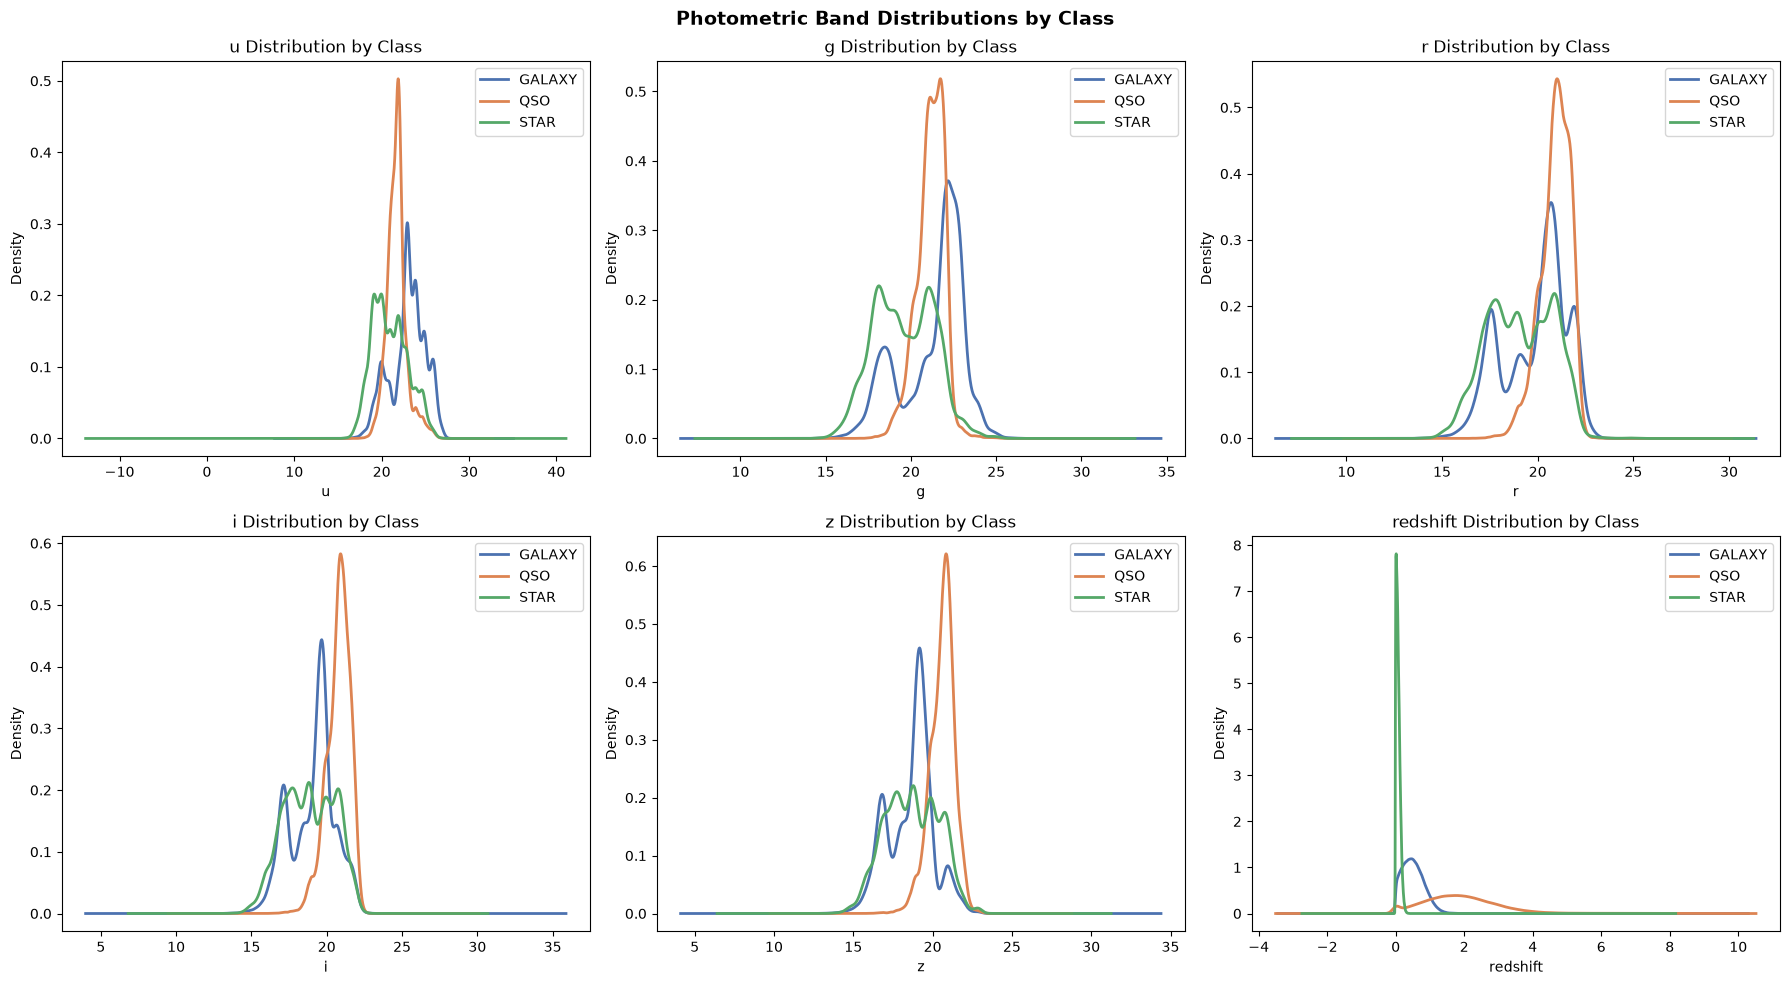

In [10]:
# Constants
CLASS_LABELS = ['GALAXY', 'QSO', 'STAR']
CLASS_COLOR_PALETTE = ['#4C72B0', '#DD8452', '#55A868']
PHOTOMETRIC_FEATURES = ['u', 'g', 'r', 'i', 'z', 'redshift']
COLUMNS_PER_ROW = 3

# Figure Setup
figure, subplot_axes = plt.subplots(2, 3, figsize=(18, 10))

# Plotting KDE for each Photometric Feature
for feature_index, feature_name in enumerate(PHOTOMETRIC_FEATURES):
    row_index = feature_index // COLUMNS_PER_ROW
    column_index = feature_index % COLUMNS_PER_ROW
    current_axis = subplot_axes[row_index][column_index]

    for class_label, class_color in zip(CLASS_LABELS, CLASS_COLOR_PALETTE):
        class_subset = train_features_extended[train_features_extended['class'] == class_label]
        feature_values = class_subset[feature_name]
        feature_values.plot.kde(
            ax=current_axis,
            label=class_label,
            color=class_color,
            linewidth=2
        )

    current_axis.set_title(f'{feature_name} Distribution by Class')
    current_axis.set_xlabel(feature_name)
    current_axis.legend()

# Output Management
plt.suptitle('Photometric Band Distributions by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../eda_bands.png', dpi=150, bbox_inches='tight')
plt.show()

### 7. Outliers

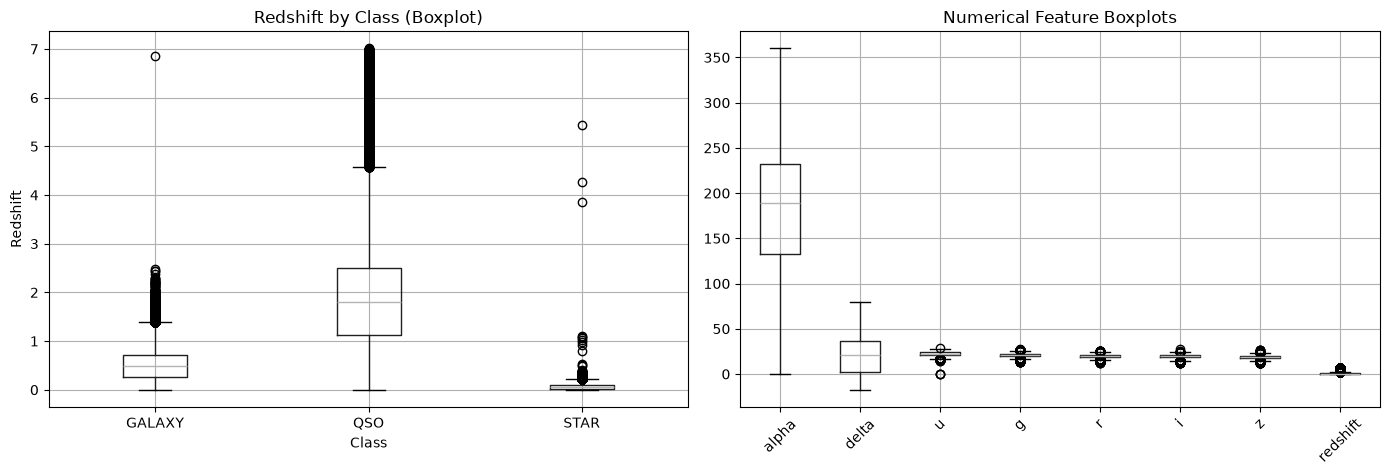

=== IQR-Based Outlier Counts ===
    feature  lower_bound  upper_bound  outlier_count  outlier_percentage
0     alpha      -17.341      381.332              0               0.000
1     delta      -49.297       88.760              0               0.000
2         u       16.639       28.207            315               0.055
3         g       16.223       25.934           2806               0.486
4         r       15.306       24.679           1677               0.290
5         i       14.855       24.060           1277               0.221
6         z       14.690       23.445           1476               0.256
7  redshift       -0.869        1.932          52590               9.109


In [11]:
# Constants
NUMERICAL_FEATURES = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
IQR_MULTIPLIER = 1.5

# Figure Setup
figure, plot_axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Box plot
training_dataset.boxplot(column='redshift', by='class', ax=plot_axes[0])
plot_axes[0].set_title('Redshift by Class (Boxplot)')
plot_axes[0].set_xlabel('Class')
plot_axes[0].set_ylabel('Redshift')
plt.sca(plot_axes[0])
plt.xticks(rotation=0)

# 2. Numerical feature boxplots
training_dataset[NUMERICAL_FEATURES].boxplot(ax=plot_axes[1], rot=45)
plot_axes[1].set_title('Numerical Feature Boxplots')

# Output Management
plt.suptitle('')
plt.tight_layout()
plt.savefig('../eda_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== IQR-Based Outlier Counts ===")
outlier_summary_rows = []
for feature_name in NUMERICAL_FEATURES:
    first_quartile = training_dataset[feature_name].quantile(0.25)
    third_quartile = training_dataset[feature_name].quantile(0.75)
    interquartile_range = third_quartile - first_quartile
    lower_bound = first_quartile - IQR_MULTIPLIER * interquartile_range
    upper_bound = third_quartile + IQR_MULTIPLIER * interquartile_range
    outlier_count = training_dataset[
        (training_dataset[feature_name] < lower_bound) | (training_dataset[feature_name] > upper_bound)
    ].shape[0]
    outlier_percentage = (outlier_count / len(training_dataset)) * 100
    outlier_summary_rows.append({
        'feature': feature_name,
        'lower_bound': round(lower_bound, 3),
        'upper_bound': round(upper_bound, 3),
        'outlier_count': outlier_count,
        'outlier_percentage': round(outlier_percentage, 3)
    })

outlier_summary_dataframe = pd.DataFrame(outlier_summary_rows)
print(outlier_summary_dataframe)

# Phase D — Target Column Check

### 8. Class Imbalance

=== Class Distribution ===
class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64

=== Class Distribution (%) ===
   GALAXY  : 377,480 (65.4%)
   QSO     : 117,143 (20.3%)
   STAR    :  82,724 (14.3%)


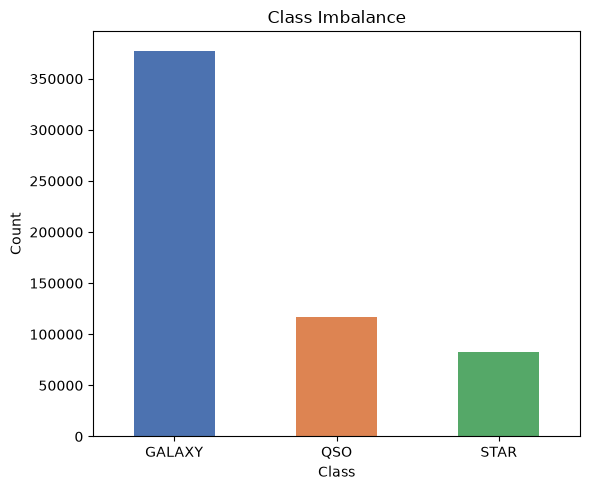

In [12]:
print("=== Class Distribution ===")
class_distribution_counts = training_dataset['class'].value_counts()
print(class_distribution_counts)

print("\n=== Class Distribution (%) ===")
total_train_records = len(training_dataset)
for class_label, record_count in class_distribution_counts.items():
    class_percentage = (record_count / total_train_records) * 100
    print(f"   {class_label:<8}: {record_count:>7,} ({class_percentage:.1f}%)")

# Constants
CLASS_LABELS = ['GALAXY', 'QSO', 'STAR']
CLASS_COLOR_PALETTE = ['#4C72B0', '#DD8452', '#55A868']

# Figure Setup
figure, plot_axis = plt.subplots(figsize=(6, 5))
class_distribution_counts.plot(kind='bar', ax=plot_axis, color=CLASS_COLOR_PALETTE)
plot_axis.set_title('Class Imbalance')
plot_axis.set_xlabel('Class')
plot_axis.set_ylabel('Count')
plot_axis.tick_params(axis='x', rotation=0)

# Output Management
plt.tight_layout()
plt.savefig('../eda_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

# Phase E — Multivariate Analysis (Columns කිහිපයක සම්බන්ධතා)

### 9. Bivariate Analysis

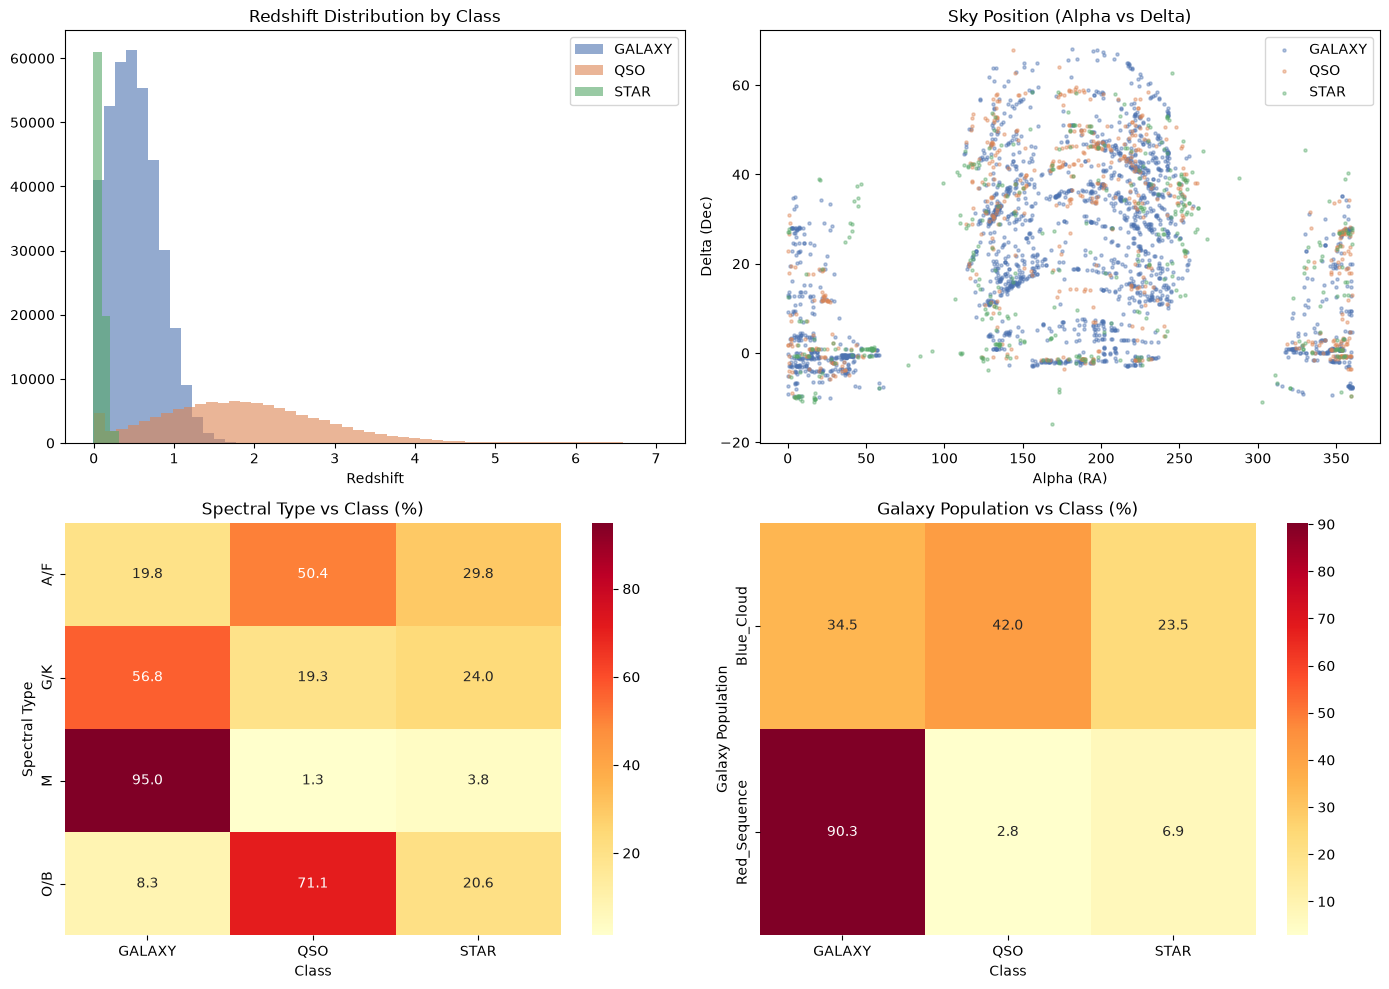

=== Redshift Statistics by Class ===
         mean    std   min    max
class                            
GALAXY  0.509  0.309 -0.01  6.860
QSO     1.876  1.070  0.00  7.011
STAR    0.068  0.064 -0.01  5.445

=== Spectral Type vs Class (Counts) ===
class          GALAXY    QSO   STAR
spectral_type                      
A/F             24240  61514  36368
G/K             61627  20921  25998
M              288023   3889  11411
O/B              3590  30819   8947

=== Galaxy Population vs Class (Counts) ===
class              GALAXY     QSO   STAR
galaxy_population                       
Blue_Cloud          88962  108274  60546
Red_Sequence       288518    8869  22178


In [13]:
# Constants
CLASS_LABELS = ['GALAXY', 'QSO', 'STAR']
CLASS_COLOR_PALETTE = ['#4C72B0', '#DD8452', '#55A868']
CLASS_COLOR_MAPPING = dict(zip(CLASS_LABELS, CLASS_COLOR_PALETTE))
RANDOM_SEED = 42
SAMPLE_SIZE = 3000
HEATMAP_COLOR_MAP = 'YlOrRd'
DECIMAL_FORMAT = '.1f'

# Figure Setup
figure, plot_axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Redshift by class
for class_name, class_color in CLASS_COLOR_MAPPING.items():
    class_subset = training_dataset[training_dataset['class'] == class_name]
    redshift_values = class_subset['redshift']
    plot_axes[0, 0].hist(redshift_values, bins=50, alpha=0.6, label=class_name, color=class_color)
plot_axes[0, 0].set_title('Redshift Distribution by Class')
plot_axes[0, 0].set_xlabel('Redshift')
plot_axes[0, 0].legend()

# 2. Alpha vs Delta scatter (sample)
dataset_sample = training_dataset.sample(n=SAMPLE_SIZE, random_state=RANDOM_SEED)
for class_name in CLASS_LABELS:
    sampled_class_subset = dataset_sample[dataset_sample['class'] == class_name]
    plot_axes[0, 1].scatter(
        sampled_class_subset['alpha'],
        sampled_class_subset['delta'],
        c=CLASS_COLOR_MAPPING[class_name],
        label=class_name,
        alpha=0.4,
        s=5
    )
plot_axes[0, 1].set_title('Sky Position (Alpha vs Delta)')
plot_axes[0, 1].set_xlabel('Alpha (RA)')
plot_axes[0, 1].set_ylabel('Delta (Dec)')
plot_axes[0, 1].legend()

# 3. Spectral type vs Class heatmap
spectral_vs_class_crosstab = pd.crosstab(
    training_dataset['spectral_type'],
    training_dataset['class'],
    normalize='index'
) * 100

sns.heatmap(
    spectral_vs_class_crosstab,
    annot=True,
    fmt=DECIMAL_FORMAT,
    cmap=HEATMAP_COLOR_MAP,
    ax=plot_axes[1, 0]
)
plot_axes[1, 0].set_title('Spectral Type vs Class (%)')
plot_axes[1, 0].set_xlabel('Class')
plot_axes[1, 0].set_ylabel('Spectral Type')

# 4. Galaxy population vs Class heatmap
galaxy_vs_class_crosstab = pd.crosstab(
    training_dataset['galaxy_population'],
    training_dataset['class'],
    normalize='index'
) * 100

sns.heatmap(
    galaxy_vs_class_crosstab,
    annot=True,
    fmt=DECIMAL_FORMAT,
    cmap=HEATMAP_COLOR_MAP,
    ax=plot_axes[1, 1]
)
plot_axes[1, 1].set_title('Galaxy Population vs Class (%)')
plot_axes[1, 1].set_xlabel('Class')
plot_axes[1, 1].set_ylabel('Galaxy Population')

# Output Management
plt.tight_layout()
plt.savefig('../eda_bivariate.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Redshift Statistics by Class ===")
redshift_summary_by_class = training_dataset.groupby('class')['redshift'].agg(['mean', 'std', 'min', 'max'])
print(redshift_summary_by_class.round(3))

print("\n=== Spectral Type vs Class (Counts) ===")
spectral_vs_class_cross_tab = pd.crosstab(training_dataset['spectral_type'], training_dataset['class'])
print(spectral_vs_class_cross_tab)

print("\n=== Galaxy Population vs Class (Counts) ===")
galaxy_vs_class_cross_tab = pd.crosstab(training_dataset['galaxy_population'], training_dataset['class'])
print(galaxy_vs_class_cross_tab)

### 10. Correlation

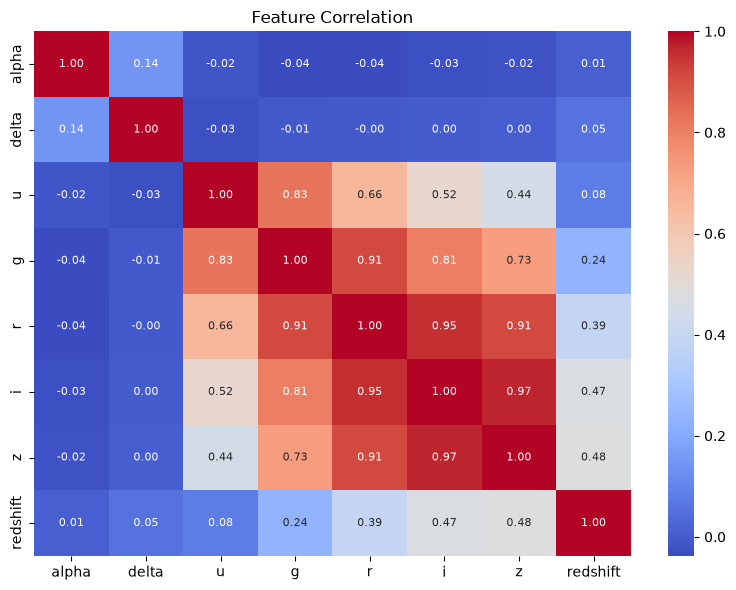

=== Highly Correlated Feature Pairs (|r| > 0.7) ===
i  z    0.968715
z  i    0.968715
i  r    0.953550
r  i    0.953550
   z    0.913341
z  r    0.913341
g  r    0.912066
r  g    0.912066
u  g    0.826880
g  u    0.826880
i  g    0.805020
g  i    0.805020
   z    0.731737
z  g    0.731737
dtype: float64


In [14]:
# Constants
NUMERICAL_FEATURES = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']

# Figure Setup
figure, plot_axis = plt.subplots(figsize=(8, 6))
numerical_data_subset = training_dataset[NUMERICAL_FEATURES]
correlation_matrix = numerical_data_subset.corr()
sns.heatmap(
    correlation_matrix,
    ax=plot_axis,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    annot_kws={"size": 8}
)
plot_axis.set_title('Feature Correlation')

# Output Management
plt.tight_layout()
plt.savefig('../eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Highly Correlated Feature Pairs (|r| > 0.7) ===")
correlation_pairs = correlation_matrix.unstack()
correlation_pairs = correlation_pairs[correlation_pairs.index.get_level_values(0) != correlation_pairs.index.get_level_values(1)]
high_correlation_pairs = correlation_pairs[correlation_pairs.abs() > 0.7].sort_values(ascending=False)
print(high_correlation_pairs)

# Summary

In [15]:
# Configurations / Formatting Constants
BORDER_LINE = "=" * 60
PERCENTAGE_MULTIPLIER = 100

print(BORDER_LINE)
print("EDA SUMMARY")
print(BORDER_LINE)

# 1. Dataset Size
train_rows_count, train_columns_count = training_dataset.shape
test_rows_count, test_columns_count = testing_dataset.shape

print("\nDataset Size:")
print(f"   Train: {train_rows_count:,} rows × {train_columns_count} columns")
print(f"   Test:  {test_rows_count:,} rows × {test_columns_count} columns")

# 2. Class Distribution
print("\nClass Distribution:")
class_value_counts = training_dataset['class'].value_counts()
total_train_records = len(training_dataset)

for class_label, record_count in class_value_counts.items():
    class_percentage = (record_count / total_train_records) * PERCENTAGE_MULTIPLIER
    print(f"   {class_label:<8}: {record_count:>7,} ({class_percentage:.1f}%)")

# 3. Duplicates & Missing Values
print("\nDuplicate Rows:", training_dataset.duplicated().sum())
total_missing_values = training_dataset.isnull().sum().sum()
print("Missing Values:", total_missing_values if total_missing_values > 0 else "NONE")

# 4. Redshift Statistics by Class
print("\nRedshift Statistics by Class:")
redshift_summary_by_class = training_dataset.groupby('class')['redshift'].agg(['mean', 'std', 'min', 'max'])
print(redshift_summary_by_class.round(3))

# 5. Insights
print("\nKey Insights:")
print("   1. Redshift is the strongest separator (STARs ≈ 0, QSOs > 1)")
print("   2. Color indices (u-g, g-r) differ significantly across classes")
print("   3. Classes are imbalanced → Balanced Accuracy metric used")
print("   4. Spectral type M dominates → mostly galaxies")
print("   5. Sky position (alpha/delta) shows no class separation")

EDA SUMMARY

Dataset Size:
   Train: 577,347 rows × 12 columns
   Test:  247,435 rows × 11 columns

Class Distribution:
   GALAXY  : 377,480 (65.4%)
   QSO     : 117,143 (20.3%)
   STAR    :  82,724 (14.3%)

Duplicate Rows: 0
Missing Values: NONE

Redshift Statistics by Class:
         mean    std   min    max
class                            
GALAXY  0.509  0.309 -0.01  6.860
QSO     1.876  1.070  0.00  7.011
STAR    0.068  0.064 -0.01  5.445

Key Insights:
   1. Redshift is the strongest separator (STARs ≈ 0, QSOs > 1)
   2. Color indices (u-g, g-r) differ significantly across classes
   3. Classes are imbalanced → Balanced Accuracy metric used
   4. Spectral type M dominates → mostly galaxies
   5. Sky position (alpha/delta) shows no class separation
